# K-Medoid Clustering with DTW

Uses `dtaidistance` (compiled C) instead of `fastdtw` (slow Python) for the distance matrix.

**Speed at window=30 on this machine:**

| Sample size | Estimated time | Memory |
|-------------|----------------|--------|
| 600 | ~0.4 min | 3 MB |
| 2 000 | ~4 min | 32 MB |
| 3 000 | ~9 min | 72 MB |
| 14 000 (all) | ~3 hours | ~1.5 GB |

**How to run:**
1. Set `SAMPLE_SIZE = None` to try the full dataset — it prints a time/memory estimate first and asks you to confirm.
2. If too slow, set `SAMPLE_SIZE = 2000` or `3000`.
3. All 14k series are still assigned to the nearest medoid at the end regardless of sample size.


## 0. Install

In [1]:
# !pip install dtaidistance
# dtaidistance uses a compiled C extension — much faster than fastdtw for full distance matrices

## 1. Imports

In [2]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

try:
    from dtaidistance import dtw as dtaidtw
    HAS_DTAI = True
except ImportError:
    HAS_DTAI = False
    warnings.warn("dtaidistance not installed.  pip install dtaidistance")

print(f"dtaidistance available: {HAS_DTAI}")

dtaidistance available: True


## 2. Configuration

In [3]:
# Each entry is (path, already_normalised)
# already_normalised=True  → skip z-normalisation (input is already z-scored)
# already_normalised=False → z-normalise before clustering
TRAIN_SETS = [
    ('../data/raw/sample_23.csv',                     False),
    ('../data/processed/sample_23_znorm.parquet',     True),
]
TEST_SET  = '../data/raw/sample_24.csv'

# None  → use all series (prints estimate + confirmation prompt before running)
# int   → use that many series (e.g. 2000)
SAMPLE_SIZE = None

CLUSTERS_COUNT       = 7
RANDOM_STATE         = 42
DTW_WINDOW           = 30    # Sakoe-Chiba band width; smaller = faster, less flexible
KMEDOID_MAX_ITER     = 60
CONSENSUS_RUNS       = 8
CONSENSUS_SAMPLE_RATIO = 0.85

# Minimum memory available in GB before warning (set to 0 to skip check)
MEMORY_WARN_GB = 4.0

PLOT_INDIVIDUAL_SERIES    = False
MAX_SERIES_PER_CLUSTER_PLOT = 300

print("Config OK")

Config OK


## 3. Data loading

In [4]:
_DATA_CACHE = {}

def load_values(filepath):
    if filepath in _DATA_CACHE:
        return _DATA_CACHE[filepath]
    path = Path(filepath)
    df   = pd.read_parquet(path) if path.suffix.lower() == '.parquet' else pd.read_csv(path)
    ids     = df.iloc[:, 0].to_numpy()
    headers = df.columns[1:].tolist()
    values  = df.iloc[:, 1:].to_numpy(dtype=np.float64, copy=False)
    _DATA_CACHE[filepath] = (ids, headers, values)
    return ids, headers, values

## 4. Copy-paste baseline

In [5]:
def calculate_copy_paste(train_path, test_path):
    _, _, data_23 = load_values(train_path)
    _, _, data_24 = load_values(test_path)
    rows = min(data_23.shape[0], data_24.shape[0])
    cols = min(data_23.shape[1], data_24.shape[1])
    d23, d24 = data_23[:rows, :cols], data_24[:rows, :cols]
    mae = float(np.abs(d23 - d24).mean())
    nz  = d24 != 0
    mape = float(np.abs((d24[nz] - d23[nz]) / d24[nz]).mean() * 100) if nz.any() else 0.0
    print(f"  MAE={mae:.4f}  MAPE={mape:.2f}%")

for ts, _ in TRAIN_SETS:
    print(f"Copy-paste baseline: {ts}")
    calculate_copy_paste(ts, TEST_SET)

Copy-paste baseline: ../data/raw/sample_23.csv
  MAE=3.8561  MAPE=323.64%
Copy-paste baseline: ../data/processed/sample_23_znorm.parquet
  MAE=9.1154  MAPE=266.84%


## 5. Distance matrix with dtaidistance

Uses the compiled C implementation with a Sakoe-Chiba window for speed.

In [6]:
def estimate_runtime(n, per_pair_ms=0.12):
    """Rough estimate based on benchmarks on this machine at window=30."""
    pairs    = n * (n - 1) // 2
    time_min = per_pair_ms / 1000 * pairs / 60
    mem_mb   = n * n * 8 / 1e6
    return time_min, mem_mb


def build_distance_matrix(series_matrix, window=DTW_WINDOW):
    """
    Build full N×N DTW distance matrix using dtaidistance (C extension).
    series_matrix : float64 array, shape (N, T)
    window        : Sakoe-Chiba band — smaller is faster.
                    window=30 on daily data preserves ~1-month warping flexibility.
    Returns condensed upper-triangle distance array (same format as scipy pdist).
    """
    if not HAS_DTAI:
        raise ImportError("dtaidistance not installed.  pip install dtaidistance")

    n = len(series_matrix)
    time_min, mem_mb = estimate_runtime(n)
    print(f"  N={n}  estimated time: {time_min:.1f} min  distance matrix: {mem_mb:.0f} MB")

    if mem_mb > MEMORY_WARN_GB * 1000:
        print(f"  WARNING: distance matrix alone needs {mem_mb/1000:.1f} GB — "
              f"make sure you have enough RAM before proceeding")

    # dtaidistance returns a condensed distance array (upper triangle, no diagonal)
    t0    = time.time()
    dists = dtaidtw.distance_matrix_fast(series_matrix, window=window)
    elapsed = time.time() - t0
    print(f"  Done in {elapsed:.1f}s  ({elapsed/60:.1f} min)")

    # Convert sparse matrix to full symmetric numpy array
    if hasattr(dists, 'toarray'):
        full = dists.toarray()
        # dtaidistance fills upper triangle; mirror it
        full = full + full.T
        np.fill_diagonal(full, 0.0)
    else:
        full = np.array(dists)

    return full


print("build_distance_matrix defined")

build_distance_matrix defined


## 6. K-Medoids and consensus clustering

In [7]:
def k_medoids_from_dist(dist_matrix, n_clusters, random_state, max_iter=KMEDOID_MAX_ITER):
    rng = np.random.default_rng(random_state)
    n   = dist_matrix.shape[0]
    medoids = rng.choice(n, size=n_clusters, replace=False)

    for _ in range(max_iter):
        labels = dist_matrix[:, medoids].argmin(axis=1)
        new_medoids = medoids.copy()

        for c in range(n_clusters):
            members = np.where(labels == c)[0]
            if len(members) == 0:
                candidates = np.setdiff1d(np.arange(n), new_medoids)
                if len(candidates) > 0:
                    new_medoids[c] = rng.choice(candidates)
                continue
            sub = dist_matrix[np.ix_(members, members)]
            new_medoids[c] = members[np.argmin(sub.sum(axis=1))]

        if np.array_equal(new_medoids, medoids):
            break
        medoids = new_medoids

    labels = dist_matrix[:, medoids].argmin(axis=1)
    return medoids, labels


def build_consensus(dist_matrix, n_clusters,
                    n_runs=CONSENSUS_RUNS,
                    sample_ratio=CONSENSUS_SAMPLE_RATIO,
                    random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    n   = dist_matrix.shape[0]
    agreement    = np.zeros((n, n), float)
    cooccurrence = np.zeros((n, n), float)

    for run in range(n_runs):
        subset_size = max(n_clusters + 1, int(sample_ratio * n))
        subset_idx  = np.sort(rng.choice(n, size=subset_size, replace=False))
        sub_dist    = dist_matrix[np.ix_(subset_idx, subset_idx)]
        _, labels   = k_medoids_from_dist(sub_dist, n_clusters, rng.integers(1 << 32))

        for i_pos, i in enumerate(subset_idx):
            for j_pos, j in enumerate(subset_idx):
                cooccurrence[i, j] += 1
                if labels[i_pos] == labels[j_pos]:
                    agreement[i, j] += 1

        print(f"  Consensus run {run+1}/{n_runs} done")

    similarity = np.divide(agreement, cooccurrence,
                           out=np.zeros_like(agreement), where=cooccurrence > 0)
    np.fill_diagonal(similarity, 1.0)
    return similarity


def medoid_indices_from_labels(dist_matrix, labels):
    medoids = []
    for cid in sorted(np.unique(labels)):
        members = np.where(labels == cid)[0]
        sub     = dist_matrix[np.ix_(members, members)]
        medoids.append(members[np.argmin(sub.sum(axis=1))])
    return medoids


print("Clustering helpers defined")

Clustering helpers defined


## 7. Main clustering pipeline

In [8]:
def z_normalise(values):
    mean = values.mean(axis=1, keepdims=True)
    std  = values.std(axis=1, keepdims=True) + 1e-6
    return (values - mean) / std


def check_normalisation(values):
    """Print a quick sanity check on row means and stds to confirm normalisation state."""
    row_means = values.mean(axis=1)
    row_stds  = values.std(axis=1)
    print(f"  Row means: {row_means.mean():.4f} (expected ~0 if z-normalised)")
    print(f"  Row stds : {row_stds.mean():.4f} (expected ~1 if z-normalised)")


def generate_clustering(ids, train_values, sample_size=SAMPLE_SIZE,
                         already_normalised=False):
    """
    1. Z-normalise (skipped if already_normalised=True)
    2. Sample series (or use all if sample_size is None)
    3. Build DTW distance matrix with dtaidistance
    4. Run consensus k-medoids
    5. Assign ALL series to nearest medoid
    Returns (full_labels, medoid_vectors, norm_values)
    """
    values = train_values.astype(np.float64)

    if already_normalised:
        print("  Input is already z-normalised — skipping normalisation step.")
        norm_values = values
    else:
        norm_values = z_normalise(values)

    print("  Normalisation check:")
    check_normalisation(norm_values)

    # Drop flat/near-zero series before clustering — they have std≈0 after normalisation
    # and will collapse into a single degenerate cluster
    row_stds   = norm_values.std(axis=1)
    active_mask = row_stds > 0.01
    n_flat      = (~active_mask).sum()
    if n_flat > 0:
        print(f"  Dropping {n_flat} flat/near-zero series before clustering "
              f"(they will be assigned to nearest medoid afterwards).")

    active_ids    = ids[active_mask]
    active_values = norm_values[active_mask]
    n_total       = len(active_values)

    # ── Decide sample ────────────────────────────────────────────────────────
    if sample_size is None:
        time_est, mem_est = estimate_runtime(n_total)
        print(f"\n  Active series: N={n_total}")
        print(f"  Estimated DTW time : {time_est:.1f} min")
        print(f"  Distance matrix    : {mem_est:.0f} MB")
        if time_est > 60:
            print(f"  NOTE: this will take a while. "
                  f"Set SAMPLE_SIZE=2000 or 3000 to run faster.")
        use_n         = n_total
        sample_ids    = active_ids
        sample_matrix = active_values
    else:
        use_n = min(sample_size, n_total)
        rng   = np.random.default_rng(RANDOM_STATE)
        pos   = np.sort(rng.choice(n_total, size=use_n, replace=False))
        sample_ids    = active_ids[pos]
        sample_matrix = active_values[pos]
        print(f"\n  Using sample: {use_n} / {n_total} active series")

    # ── Distance matrix ───────────────────────────────────────────────────────
    print(f"  Building DTW distance matrix (window={DTW_WINDOW})...")
    dist_matrix = build_distance_matrix(sample_matrix, window=DTW_WINDOW)

    # ── Consensus clustering ──────────────────────────────────────────────────
    print(f"\n  Running consensus clustering ({CONSENSUS_RUNS} runs)...")
    similarity     = build_consensus(dist_matrix, CLUSTERS_COUNT)
    consensus_dist = 1.0 - similarity
    np.fill_diagonal(consensus_dist, 0.0)

    agg           = AgglomerativeClustering(n_clusters=CLUSTERS_COUNT,
                                            metric='precomputed', linkage='average')
    sample_labels = agg.fit_predict(consensus_dist)

    # ── Medoid vectors ────────────────────────────────────────────────────────
    medoid_positions = medoid_indices_from_labels(dist_matrix, sample_labels)
    medoid_vectors   = sample_matrix[medoid_positions]

    # ── Assign ALL series (including flat ones) to nearest medoid ─────────────
    # Euclidean on z-norm is fast and good enough for the assignment step
    diff        = norm_values[:, None, :] - medoid_vectors[None, :, :]
    all_dists   = np.sqrt((diff ** 2).sum(axis=2))
    full_labels = all_dists.argmin(axis=1)

    sizes = np.bincount(full_labels, minlength=CLUSTERS_COUNT).tolist()
    print(f"\n  Cluster sizes (all series including flat): {sizes}")
    print(f"  Total assigned: {len(full_labels)}")

    return full_labels, medoid_vectors, norm_values


print("generate_clustering defined")

generate_clustering defined


## 8. Run and save

In [9]:
def make_output_dir():
    for base in [Path('outputs/kmedoid'), Path('notebooks/outputs/kmedoid')]:
        if base.parent.exists():
            base.mkdir(parents=True, exist_ok=True)
            return base
    fallback = Path('outputs/kmedoid')
    fallback.mkdir(parents=True, exist_ok=True)
    return fallback


output_dir = make_output_dir()
clusterings = []

for train_set, already_norm in TRAIN_SETS:
    print(f"\n{'='*60}")
    print(f"Train set: {train_set}  (already_normalised={already_norm})")
    print('='*60)

    ids, _, train_values = load_values(train_set)
    labels, medoid_vectors, norm_values = generate_clustering(
        ids, train_values, already_normalised=already_norm
    )

    export_df  = pd.DataFrame({'ID': ids, 'cluster': labels})
    fname      = f"kmedoid_cluster_labels_{Path(train_set).stem}.csv"
    export_path = output_dir / fname
    export_df.to_csv(export_path, index=False)
    print(f"Saved: {export_path}")

    clusterings.append((train_set, labels, medoid_vectors, norm_values))

print("\nAll clusterings complete.")


Train set: ../data/raw/sample_23.csv  (already_normalised=False)
  Normalisation check:
  Row means: -0.0000 (expected ~0 if z-normalised)
  Row stds : 0.9912 (expected ~1 if z-normalised)
  Dropping 154 flat/near-zero series before clustering (they will be assigned to nearest medoid afterwards).

  Active series: N=17393
  Estimated DTW time : 302.5 min
  Distance matrix    : 2420 MB
  NOTE: this will take a while. Set SAMPLE_SIZE=2000 or 3000 to run faster.
  Building DTW distance matrix (window=30)...
  N=17393  estimated time: 302.5 min  distance matrix: 2420 MB
  Done in 2253.2s  (37.6 min)

  Running consensus clustering (8 runs)...
  Consensus run 1/8 done
  Consensus run 2/8 done
  Consensus run 3/8 done
  Consensus run 4/8 done
  Consensus run 5/8 done
  Consensus run 6/8 done
  Consensus run 7/8 done
  Consensus run 8/8 done

  Cluster sizes (all series including flat): [980, 995, 931, 2412, 9359, 2265, 605]
  Total assigned: 17547
Saved: outputs/kmedoid/kmedoid_cluster_labe

## 9. Plots


Plots for: ../data/raw/sample_23.csv


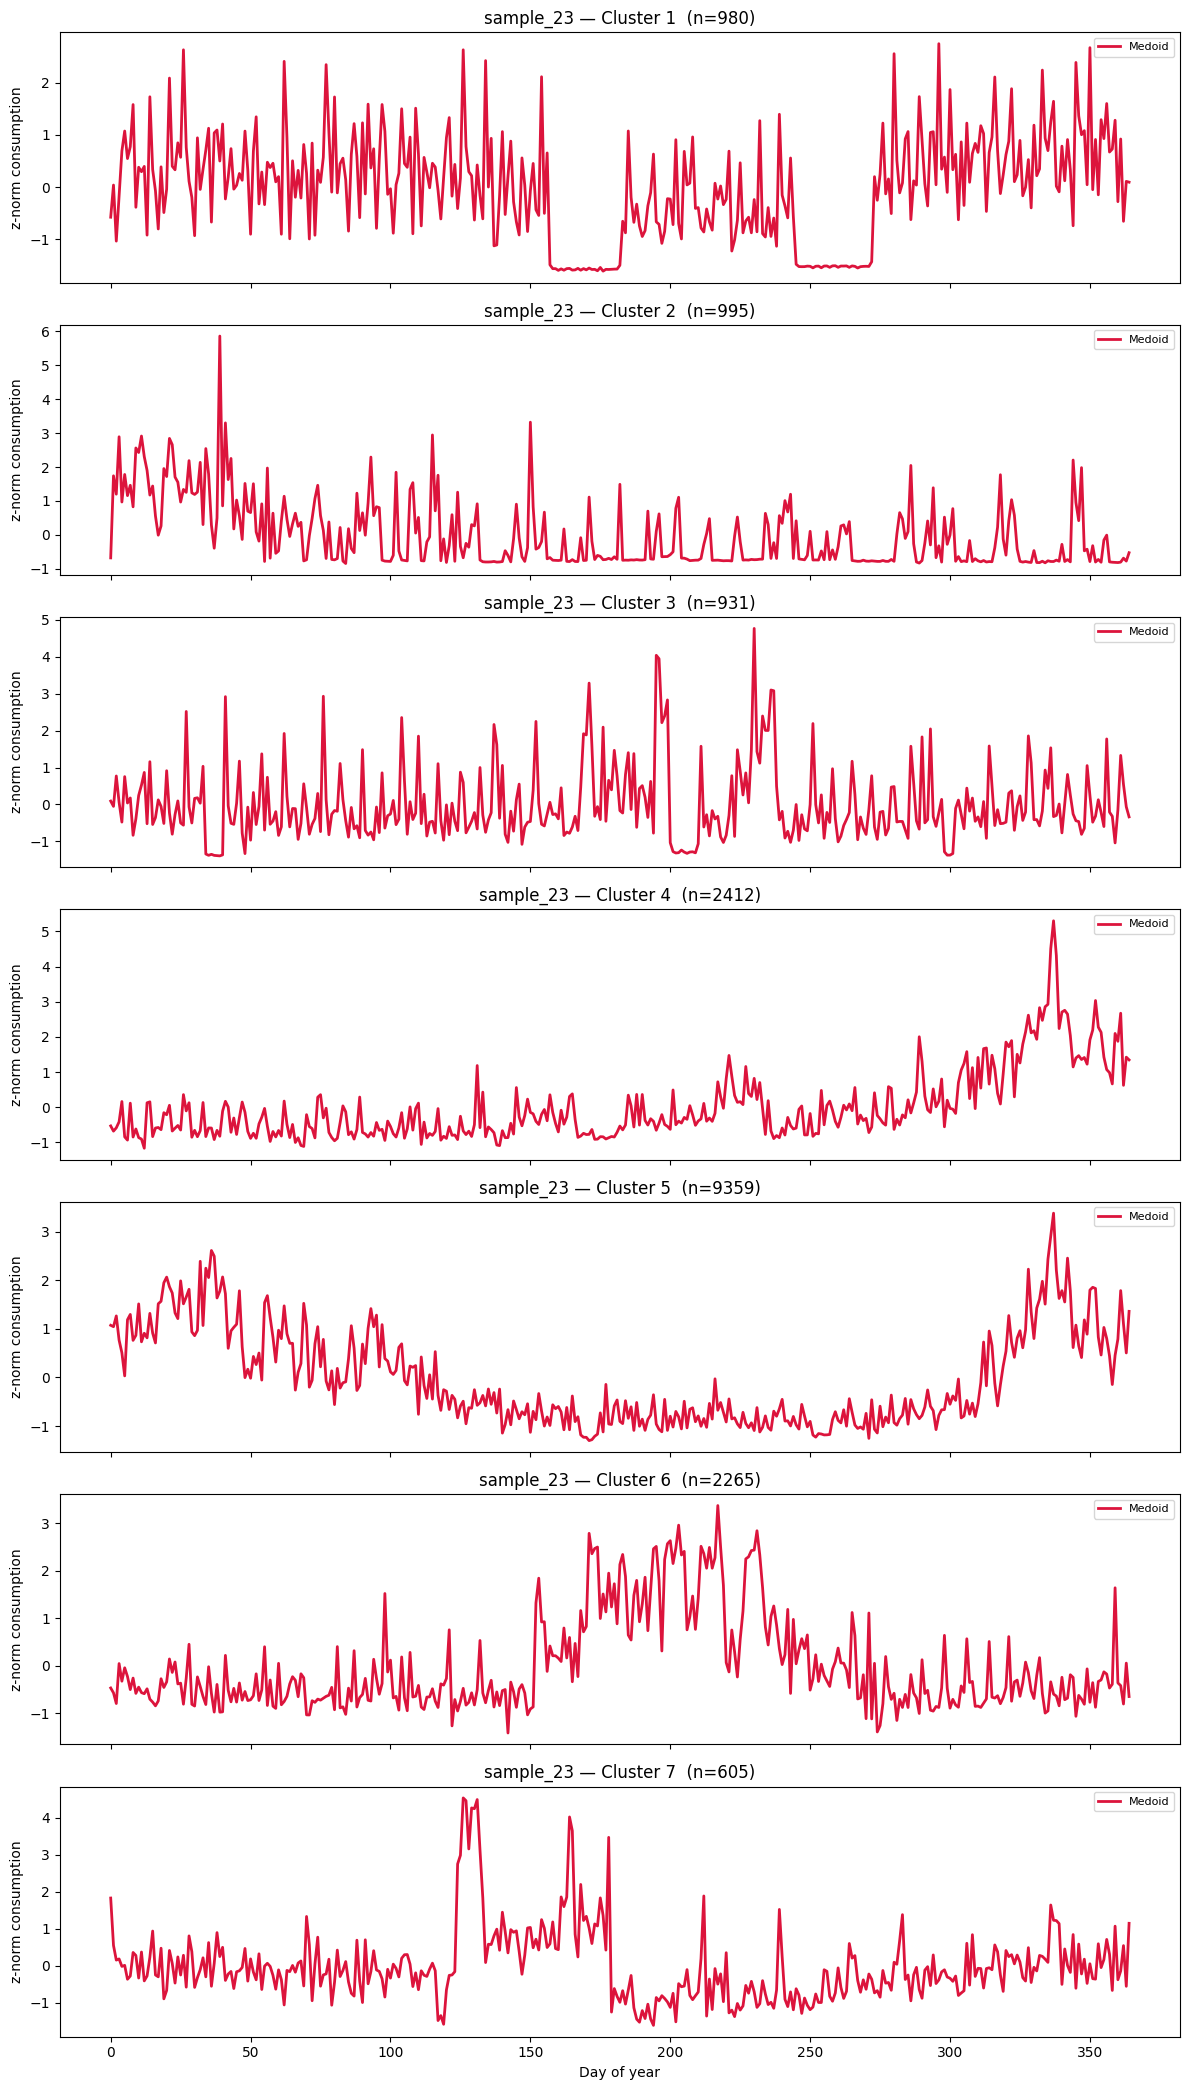

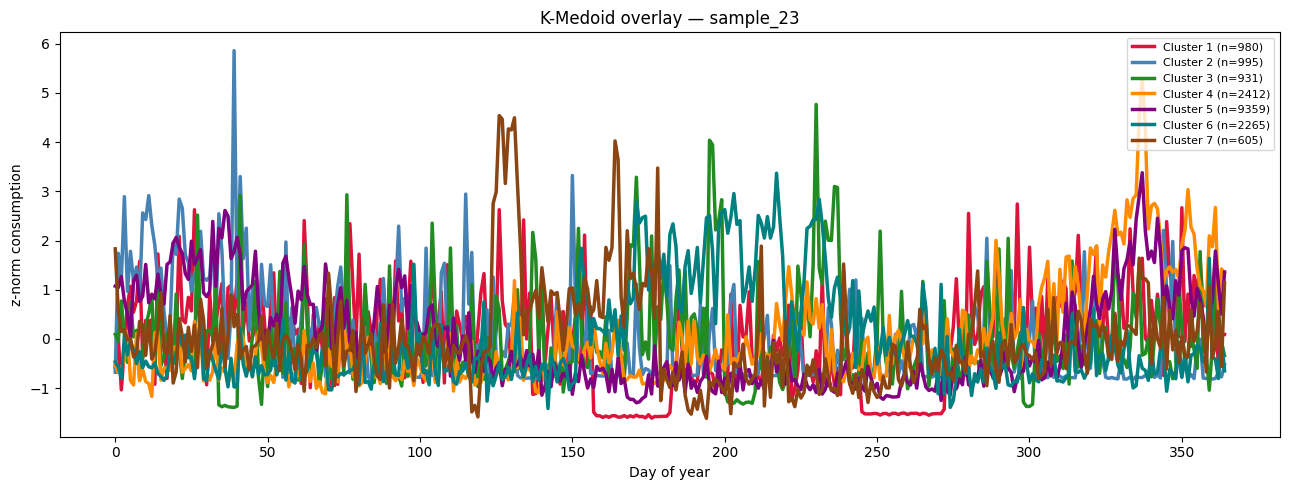


Plots for: ../data/processed/sample_23_znorm.parquet


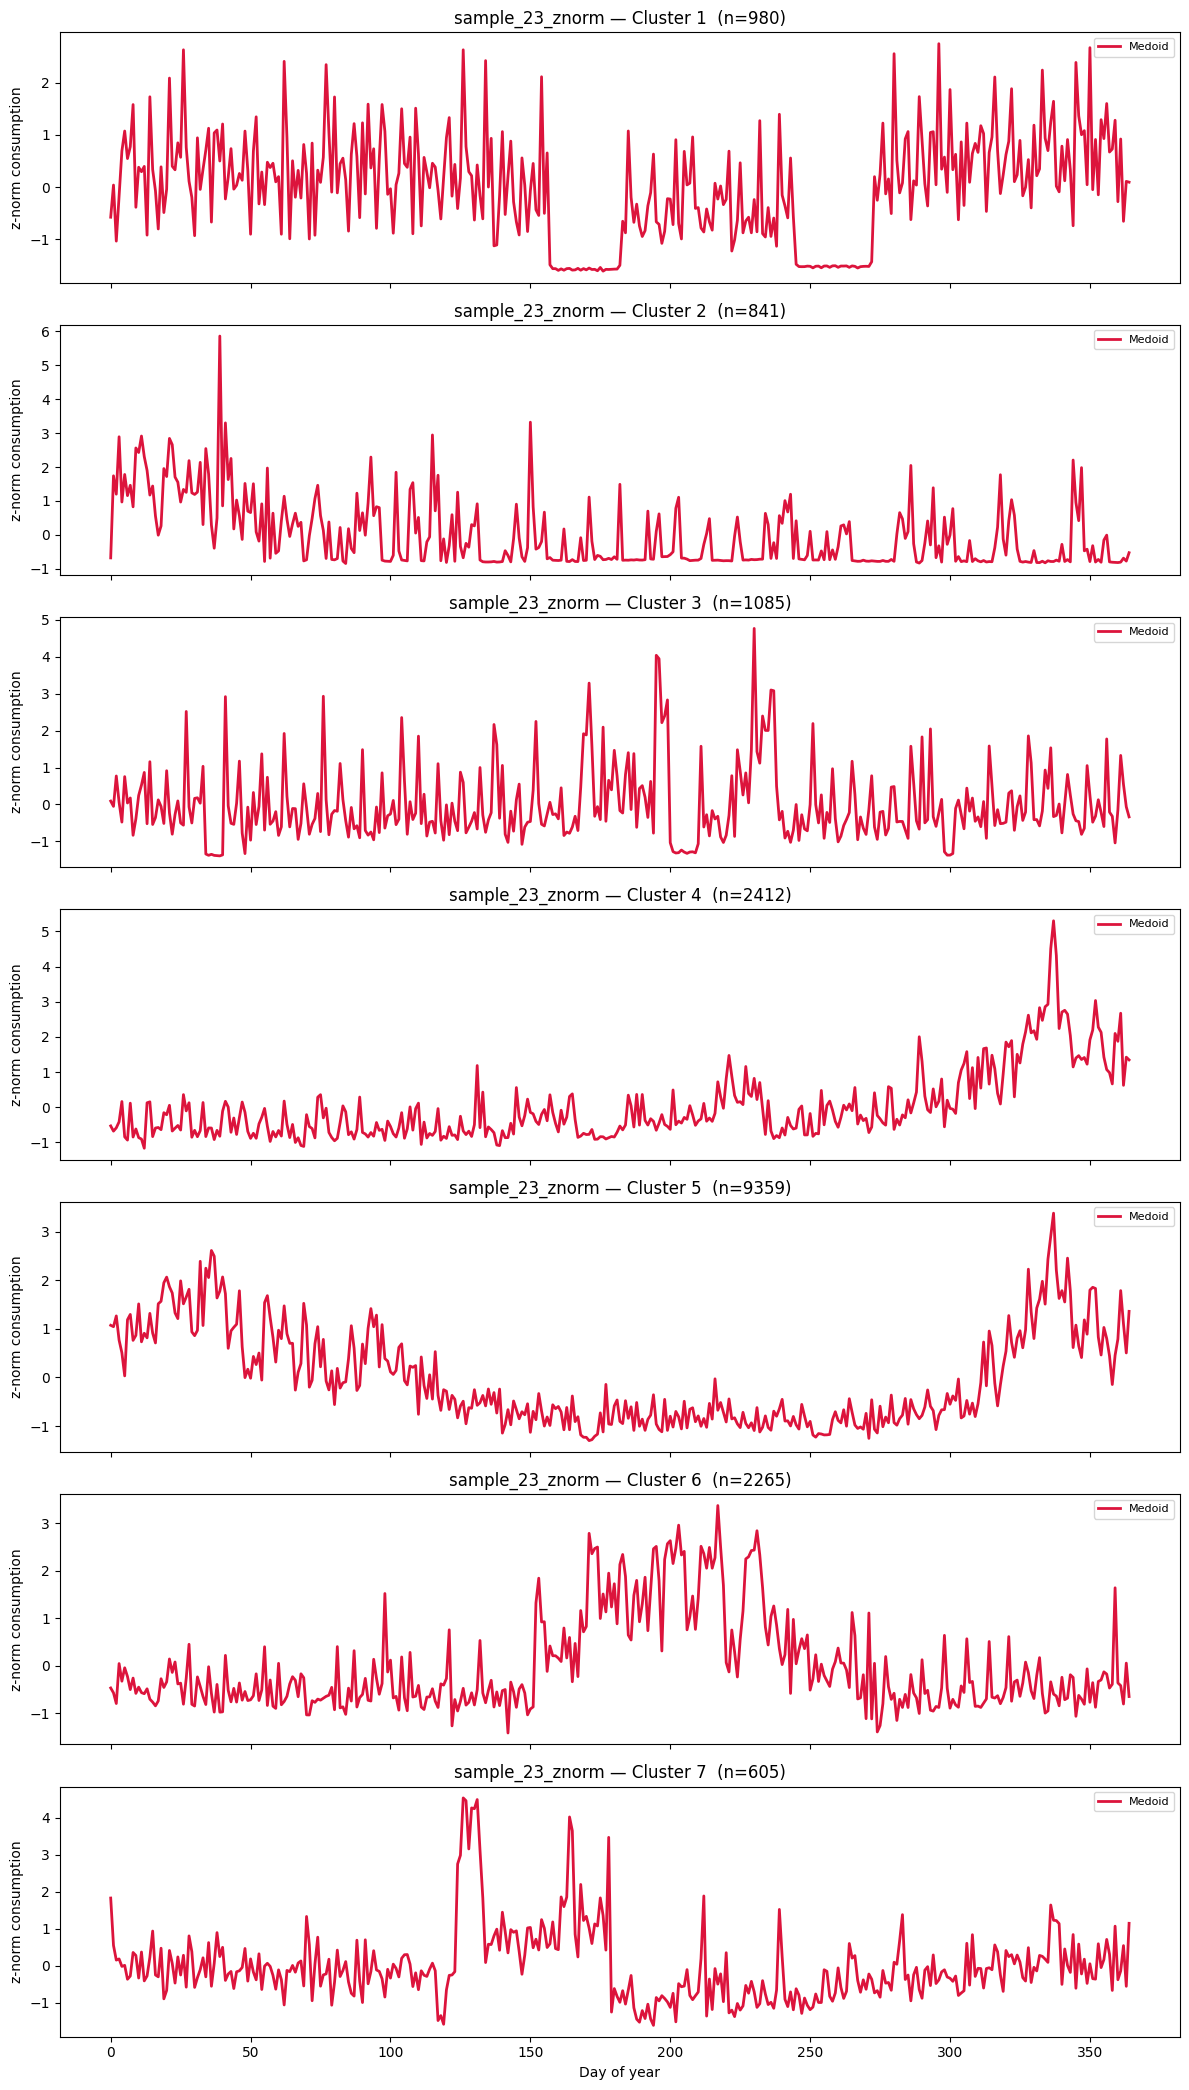

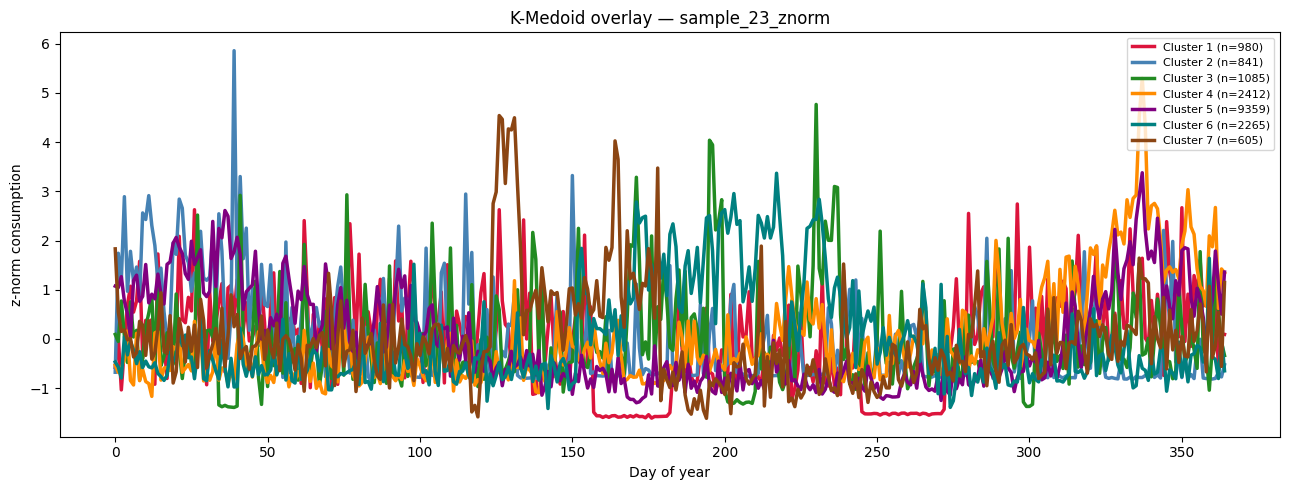

In [10]:
def plot_clusters(labels, medoid_vectors, norm_values,
                  plot_individual=PLOT_INDIVIDUAL_SERIES,
                  max_per_cluster=MAX_SERIES_PER_CLUSTER_PLOT,
                  title_prefix=""):
    k = len(medoid_vectors)
    fig, axes = plt.subplots(k, 1, figsize=(12, 3*k), sharex=True)
    if k == 1:
        axes = [axes]

    for i in range(k):
        cluster_data = norm_values[labels == i]
        if plot_individual and len(cluster_data) > 0:
            sample_n = min(max_per_cluster, len(cluster_data))
            idx = np.random.choice(len(cluster_data), size=sample_n, replace=False)
            for s in cluster_data[idx]:
                axes[i].plot(s, color='gray', alpha=0.06, linewidth=0.5)
        axes[i].plot(medoid_vectors[i], color='crimson', linewidth=2,
                     label='Medoid')
        axes[i].set_title(f"{title_prefix}Cluster {i+1}  (n={len(cluster_data)})")
        axes[i].set_ylabel("z-norm consumption")
        axes[i].legend(fontsize=8)

    plt.xlabel("Day of year")
    plt.tight_layout()
    plt.show()


def plot_overlay(labels, medoid_vectors, norm_values,
                 plot_individual=PLOT_INDIVIDUAL_SERIES,
                 max_per_cluster=MAX_SERIES_PER_CLUSTER_PLOT,
                 title="K-Medoid clusters"):
    colors = ['crimson','steelblue','forestgreen','darkorange',
              'purple','teal','saddlebrown','olive','navy','deeppink']
    plt.figure(figsize=(13, 5))
    for i in range(len(medoid_vectors)):
        data = norm_values[labels == i]
        col  = colors[i % len(colors)]
        if plot_individual and len(data) > 0:
            n = min(max_per_cluster, len(data))
            for s in data[np.random.choice(len(data), n, replace=False)]:
                plt.plot(s, color=col, alpha=0.04, linewidth=0.4)
        plt.plot(medoid_vectors[i], color=col, linewidth=2.5,
                 label=f"Cluster {i+1} (n={len(data)})")
    plt.title(title)
    plt.xlabel("Day of year")
    plt.ylabel("z-norm consumption")
    plt.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()


for train_set, labels, medoid_vectors, norm_values in clusterings:
    stem = Path(train_set).stem
    print(f"\nPlots for: {train_set}")
    plot_clusters(labels, medoid_vectors, norm_values, title_prefix=f"{stem} — ")
    plot_overlay(labels, medoid_vectors, norm_values,
                 title=f"K-Medoid overlay — {stem}")

In [11]:
from sklearn.metrics import silhouette_score


def _silhouette(X: np.ndarray, labels: np.ndarray) -> float:
    unique = np.unique(labels[labels >= 0])
    if len(unique) < 2 or len(unique) >= len(X):
        return -1.0
    try:
        return float(
            silhouette_score(
                X, labels, sample_size=min(5000, len(X)), random_state=RANDOM_STATE
            )
        )
    except Exception:
        return -1.0


# silothette score for each clustering
for train_set, labels, medoid_vectors, norm_values in clusterings:
    score = _silhouette(norm_values, labels)
    print(f"Silhouette score for {train_set}: {score:.4f}")

Silhouette score for ../data/raw/sample_23.csv: 0.0458
Silhouette score for ../data/processed/sample_23_znorm.parquet: 0.0496
